# Notebook 2 - Supervised Modeling (Classical + Deep Time Series)
Scientific modeling notebook:
- train/test split + cross-validation,
- 3 classical ML models,
- 3 deep temporal models,
- modality-level interpretation (emotion, mimic, face points, Tobii),
- model persistence and reproducible inference.

In [1]:
from pathlib import Path
from analysis_tools.research_tasks import run_modeling

ROOT = Path.cwd()
result = run_modeling(
    data_root=ROOT / "data",
    eda_root=ROOT / "Analysis_Result" / "01_EDA",
    out_root=ROOT / "Analysis_Result" / "02_Modeling",
)
print("Modeling finished:")
for k, v in result.items():
    print(f"{k}: {v}")

C:\Users\ENU\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
6 fits failed out of a total of 18.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\ENU\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\ENU\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\ENU\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\

Modeling finished:
n_samples: 99
n_features: 149
best_classical_model: LogisticRegression
best_deep_model: BiLSTM_TS
classical_roc_auc: 0.9758592471358429
deep_roc_auc: 0.9210310965630115
classical_holdout_roc_auc: 0.9852941176470589
deep_holdout_roc_auc: 0.9800000000000001
model_tables: C:\Users\ENU\Desktop\autism_gaze_dataset\Analysis_Result\02_Modeling\tables
model_figures: C:\Users\ENU\Desktop\autism_gaze_dataset\Analysis_Result\02_Modeling\figures
models_dir: C:\Users\ENU\Desktop\autism_gaze_dataset\Analysis_Result\02_Modeling\models


,accuracy,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc,model
0,0.898990,0.897709,0.888889,0.923077,0.905660,0.977556,0.975859,LogisticRegression
1,0.888889,0.887070,0.872727,0.923077,0.897196,0.965582,0.957856,SVC_RBF
2,0.878788,0.879501,0.900000,0.865385,0.882353,0.952978,0.927373,RandomForest


,accuracy,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc,model,n_train,n_test
0,0.878788,0.875000,0.809524,1.000000,0.894737,0.987272,0.985294,LogisticRegression,66.0,33.0
1,0.848485,0.843750,0.772727,1.000000,0.871795,0.987716,0.985294,SVC_RBF,66.0,33.0
2,0.878788,0.876838,0.842105,0.941176,0.888889,0.982260,0.977941,RandomForest,66.0,33.0


,accuracy,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc,model
0,0.878788,0.879501,0.900000,0.865385,0.882353,0.917250,0.921031,BiLSTM_TS
1,0.828283,0.829378,0.857143,0.807692,0.831683,0.917911,0.901391,CNN1D_TS
2,0.818182,0.816694,0.814815,0.846154,0.830189,0.867815,0.887070,Transformer_TS


,accuracy,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc,model,n_train,n_test
0,0.90,0.90,0.833333,1.0,0.909091,0.983333,0.98,BiLSTM_TS,79.0,20.0
1,0.90,0.90,0.833333,1.0,0.909091,0.980909,0.98,CNN1D_TS,79.0,20.0
2,0.85,0.85,0.818182,0.9,0.857143,0.948485,0.93,Transformer_TS,79.0,20.0


,model,roc_auc,pr_auc,balanced_accuracy,f1,family
0,LogisticRegression,0.975859,0.977556,0.897709,0.905660,classical
1,SVC_RBF,0.957856,0.965582,0.887070,0.897196,classical
2,RandomForest,0.927373,0.952978,0.879501,0.882353,classical
3,BiLSTM_TS,0.921031,0.917250,0.879501,0.882353,deep
4,CNN1D_TS,0.901391,0.917911,0.829378,0.831683,deep
5,Transformer_TS,0.887070,0.867815,0.816694,0.830189,deep


,modality,n_features,cv_roc_auc
0,tobii,62.0,0.944708
1,mimic,44.0,0.916340
2,face_points,13.0,0.854829
3,emotion,3.0,0.682099


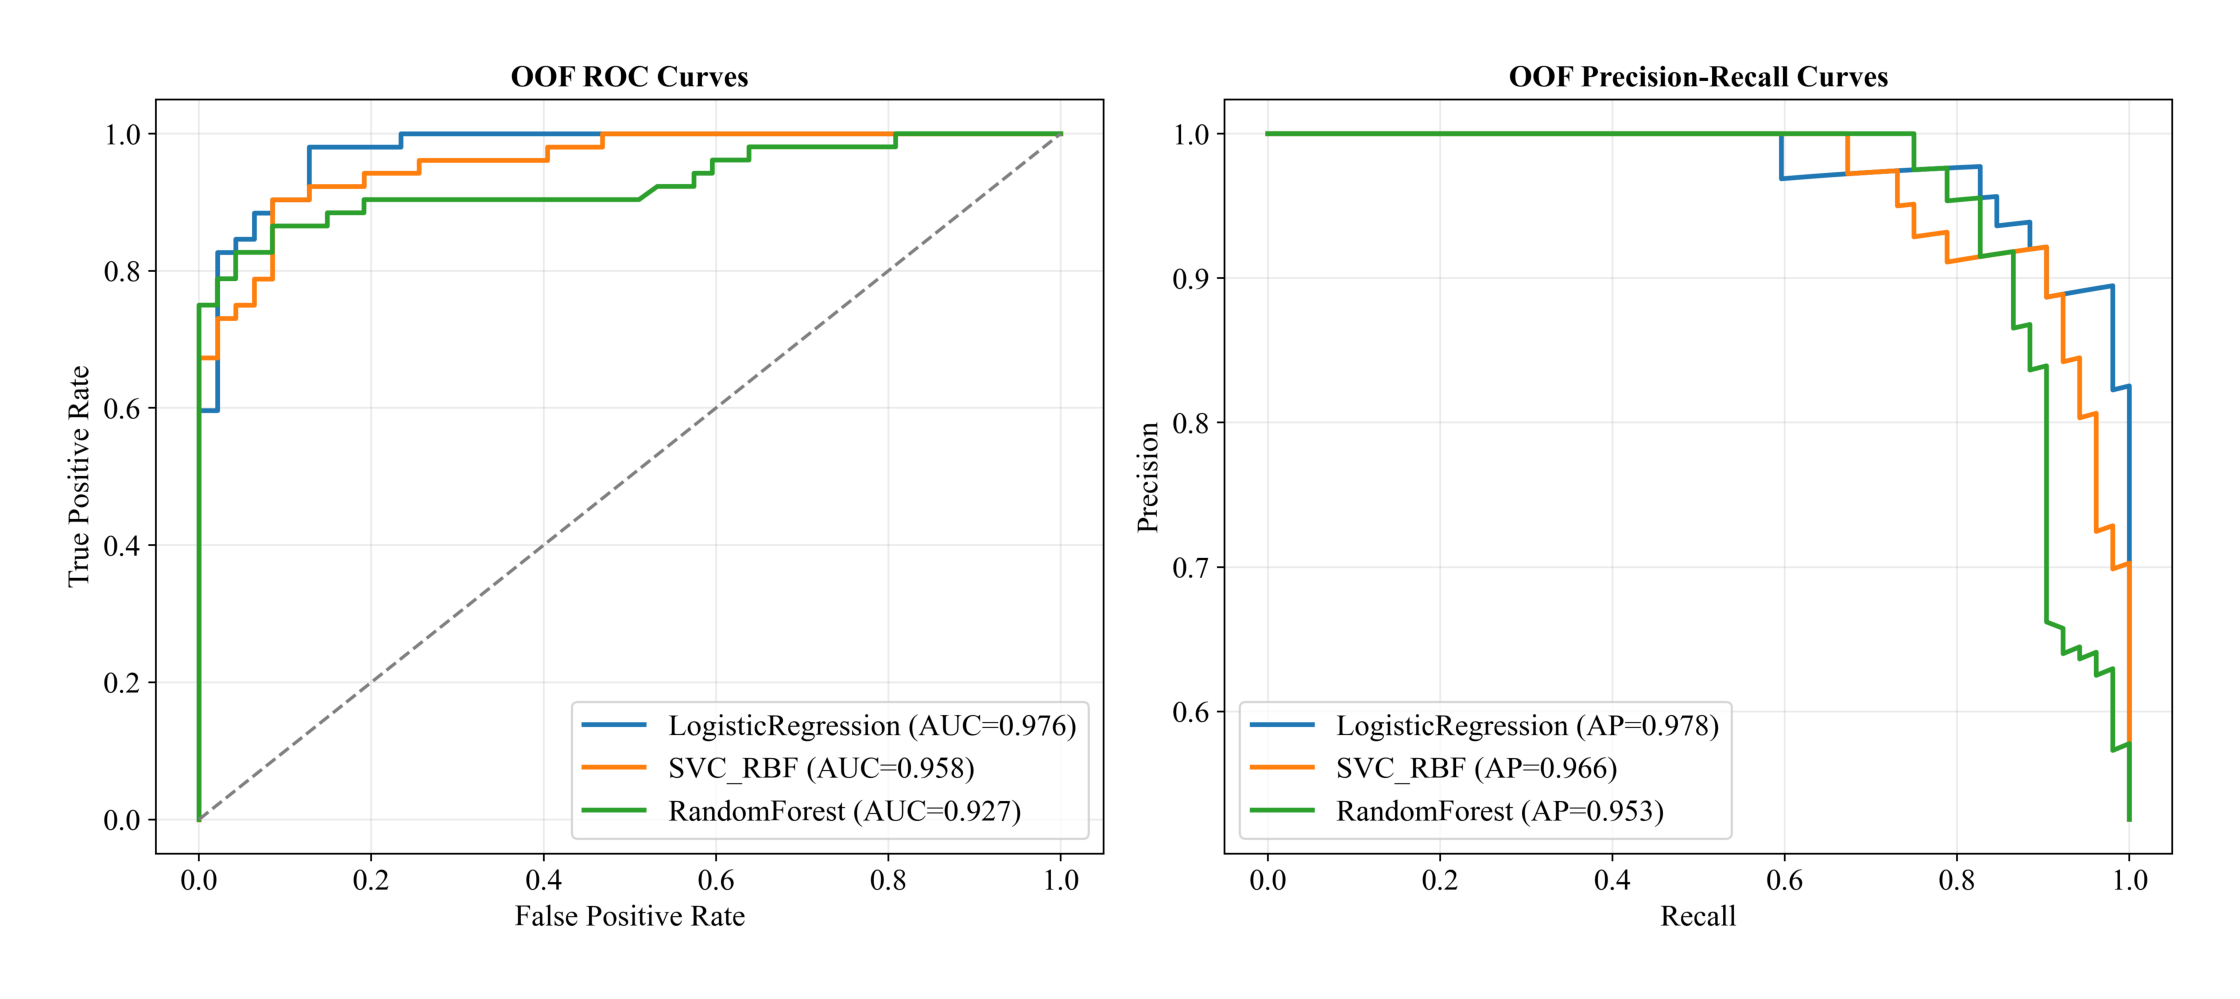

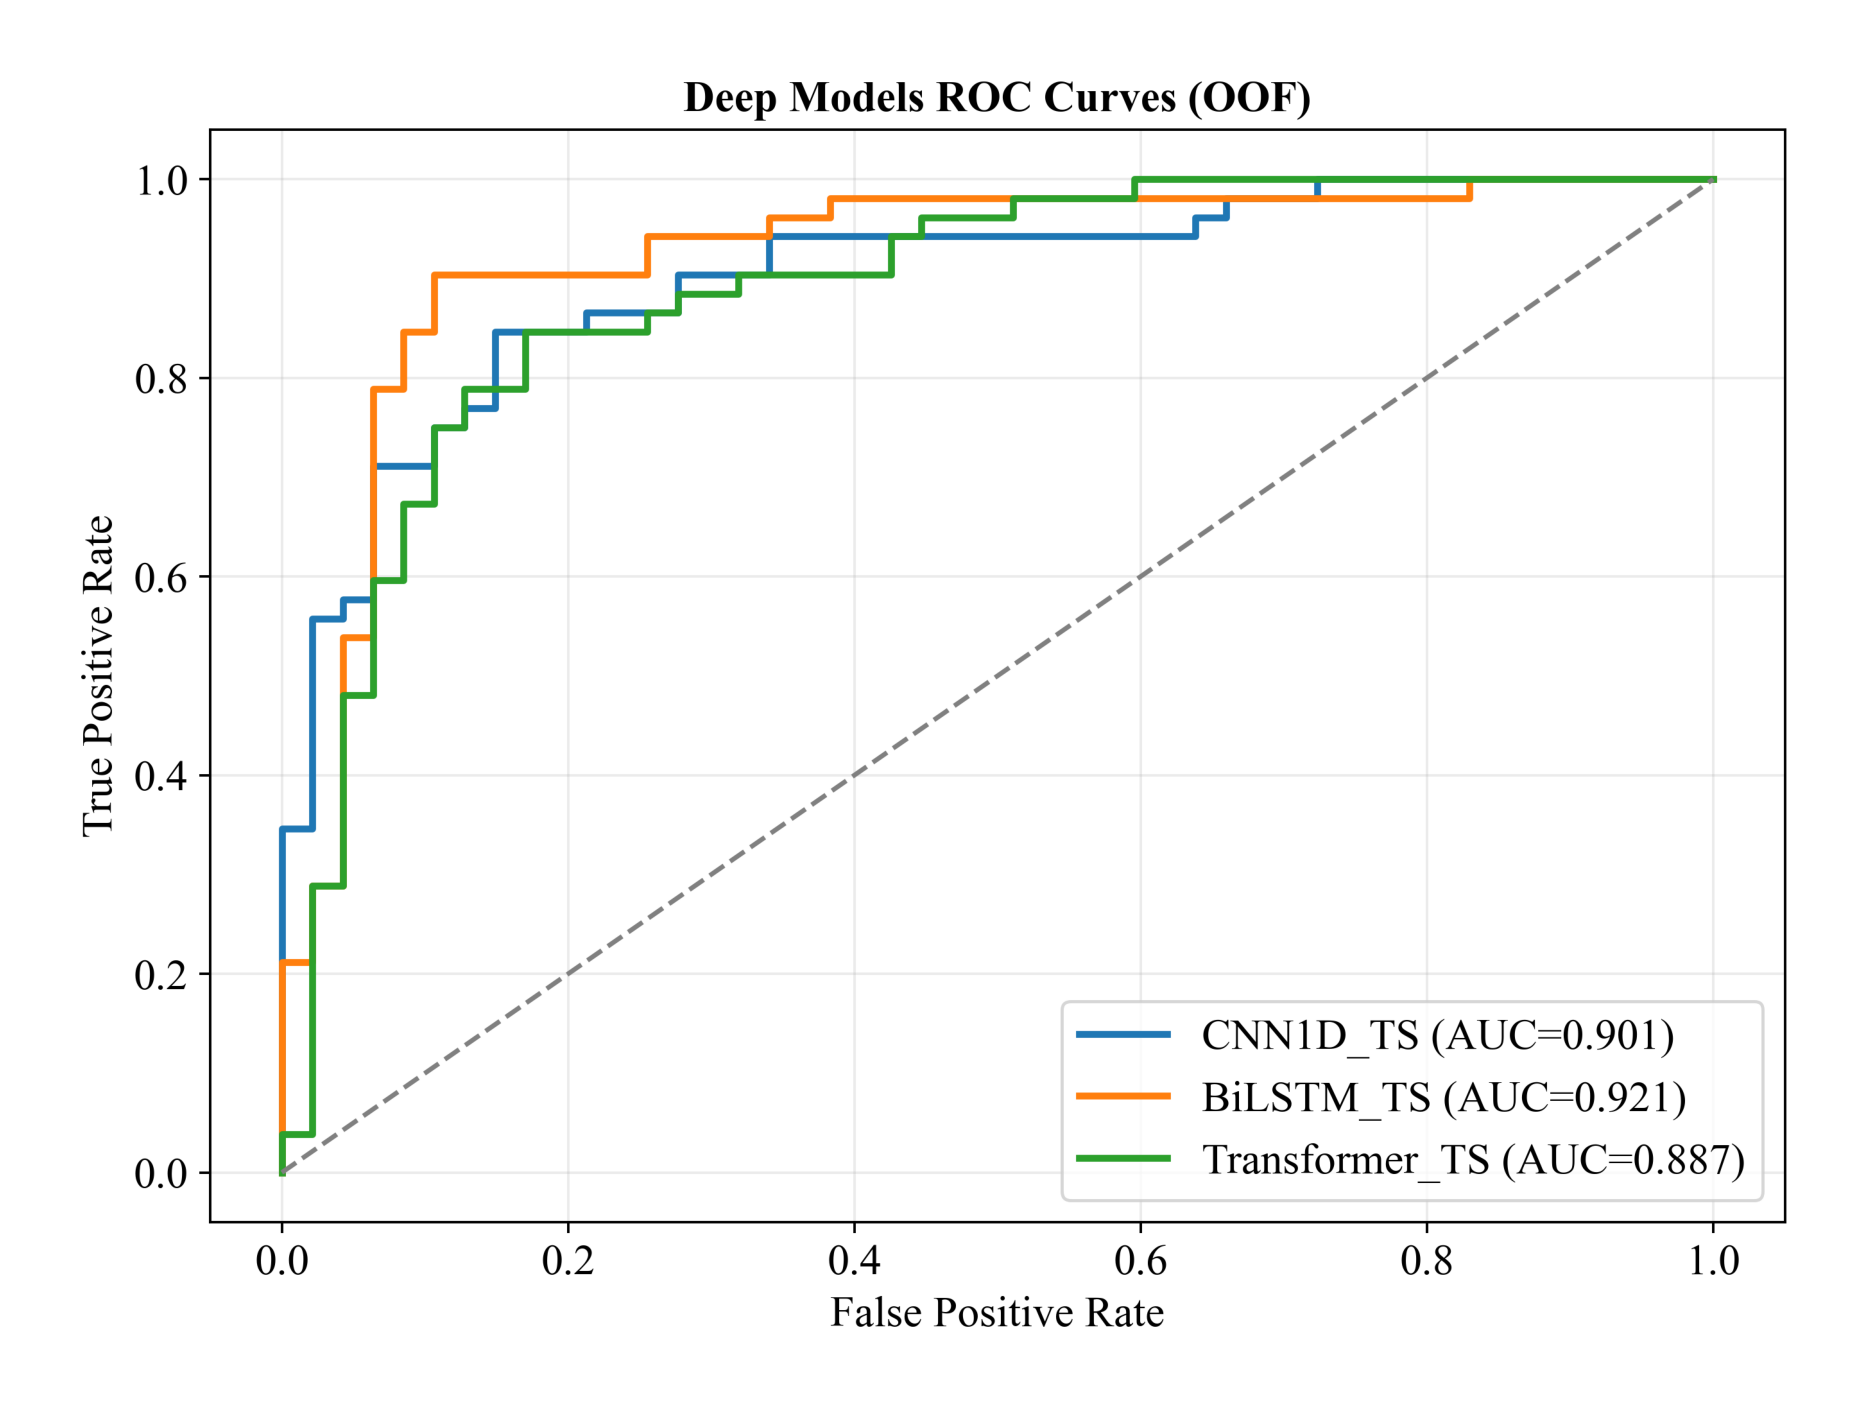

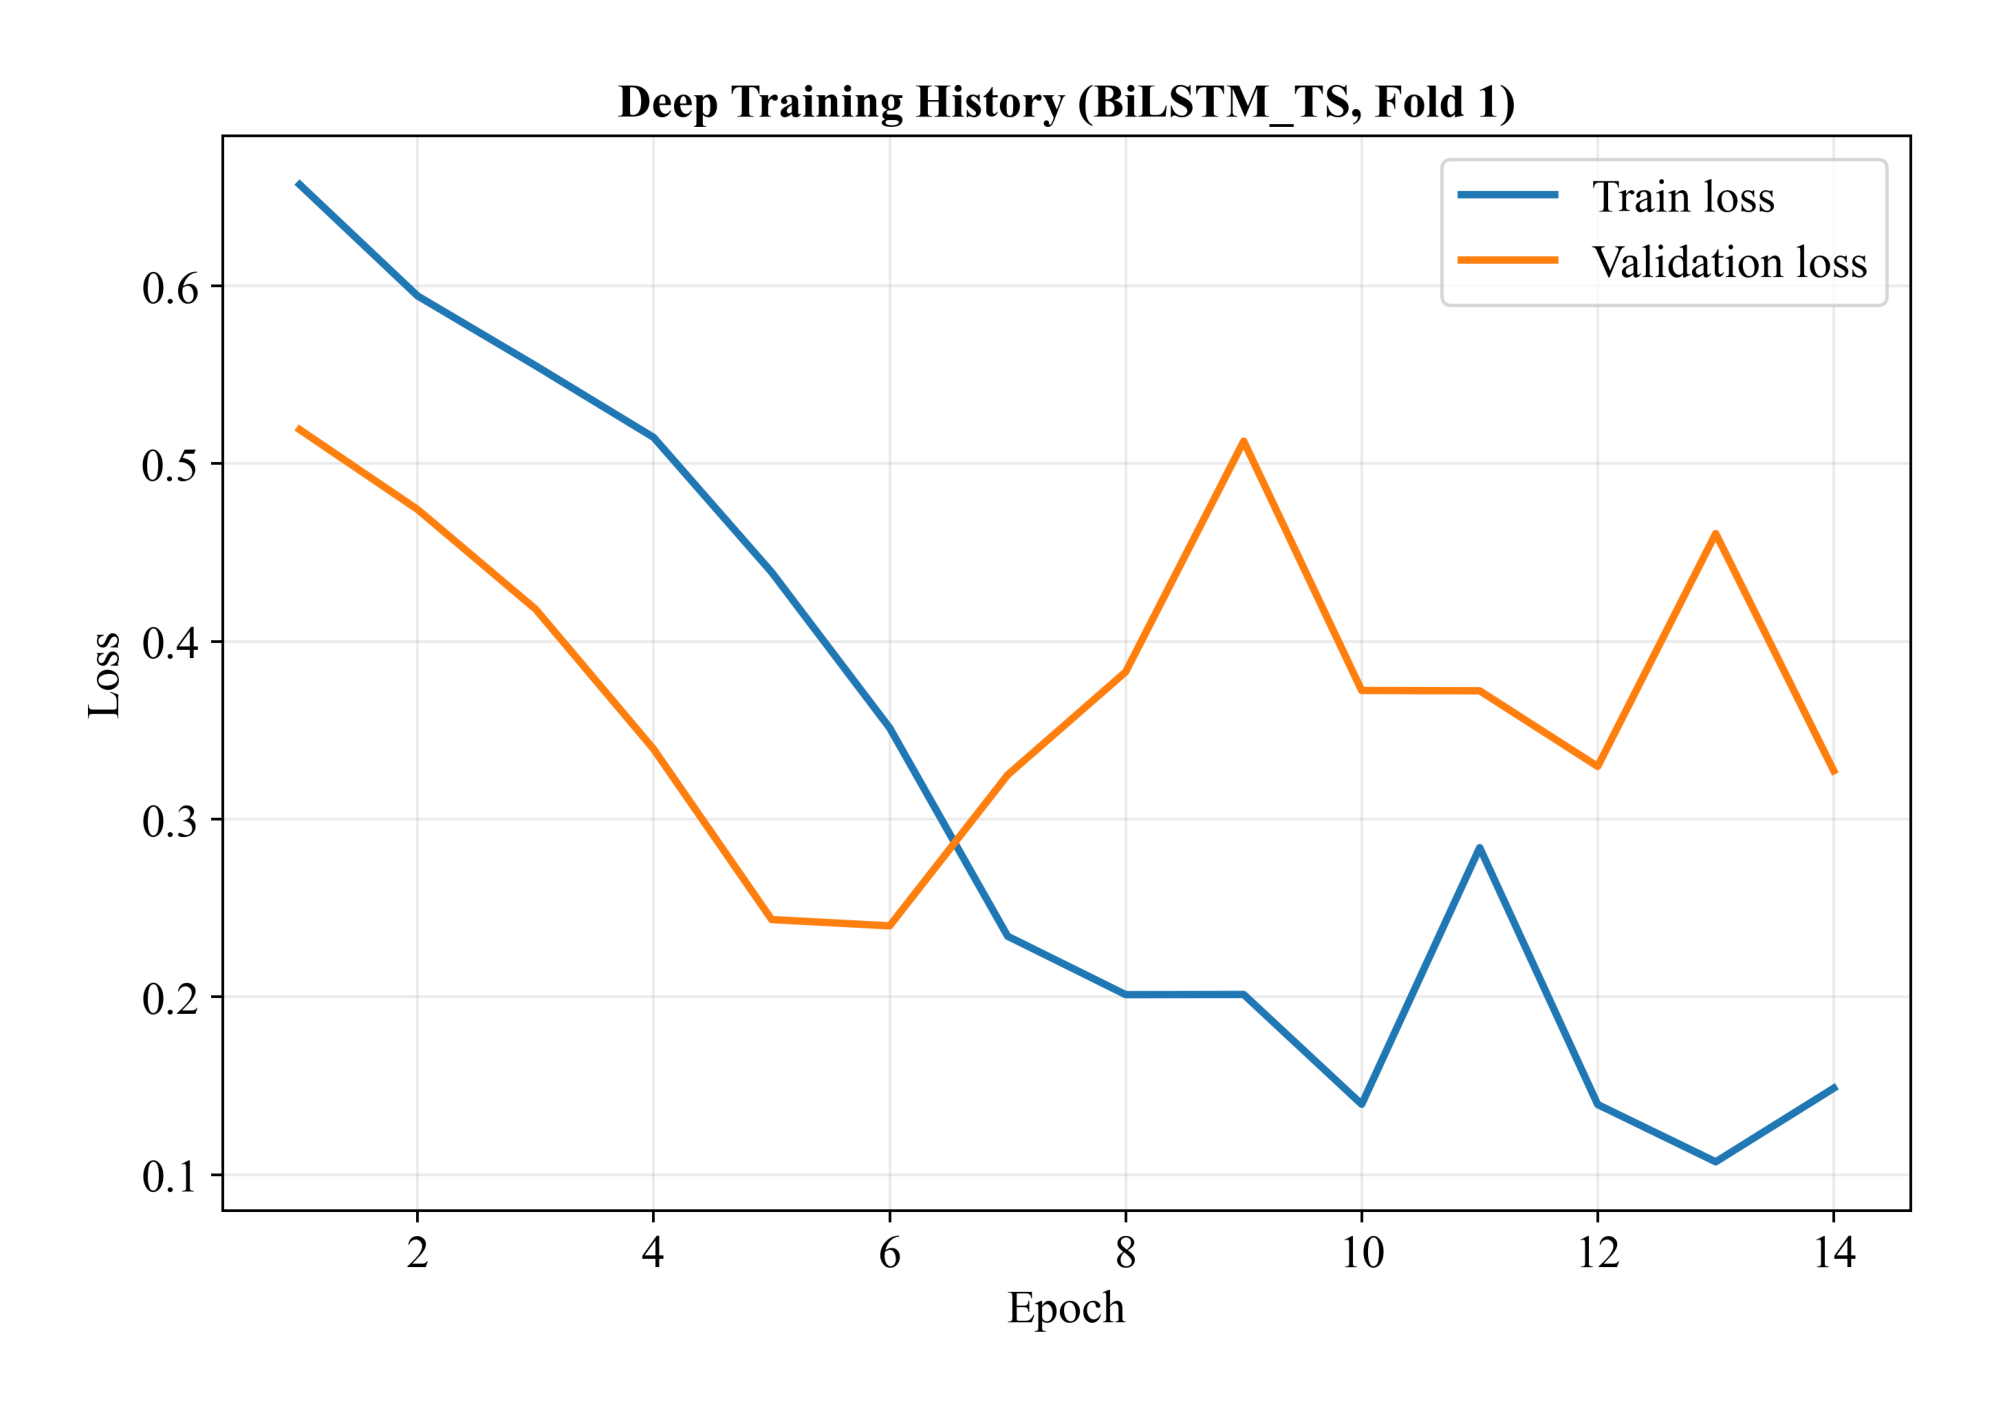

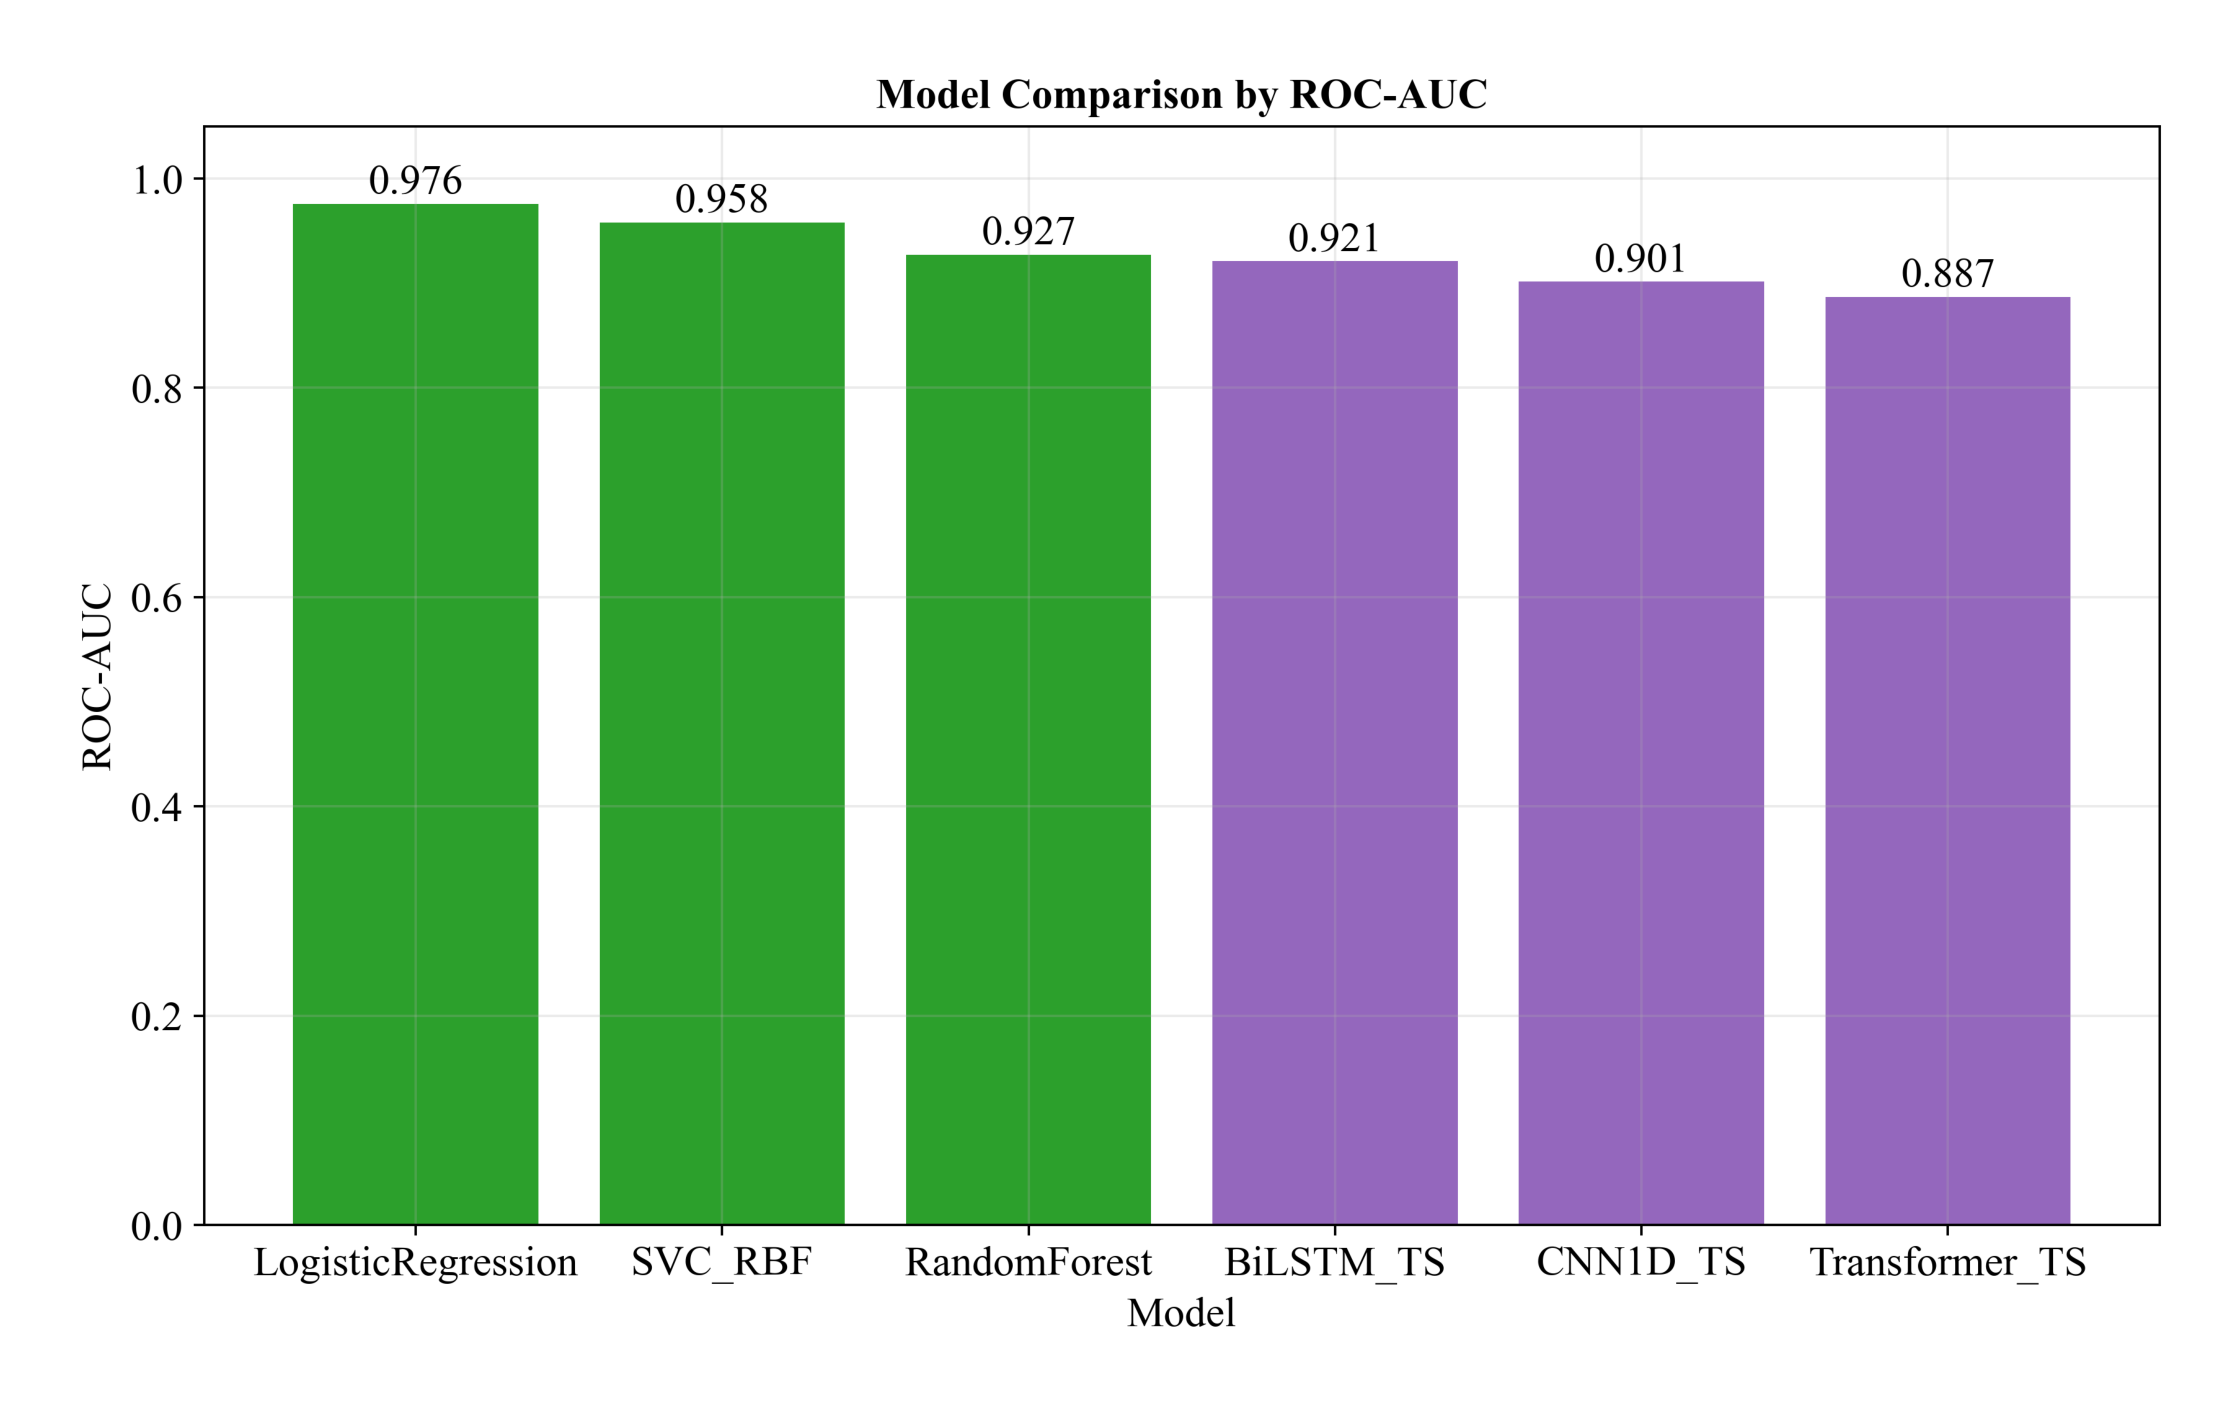

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd()
TAB = ROOT / "Analysis_Result" / "02_Modeling" / "tables"
FIG = ROOT / "Analysis_Result" / "02_Modeling" / "figures"

display(pd.read_csv(TAB / "classical_oof_metrics.csv"))
display(pd.read_csv(TAB / "classical_holdout_metrics.csv"))
display(pd.read_csv(TAB / "deep_cv_metrics.csv"))
display(pd.read_csv(TAB / "deep_holdout_metrics.csv"))
display(pd.read_csv(TAB / "combined_model_comparison.csv"))
display(pd.read_csv(TAB / "modality_model_quality.csv"))

figure_specs = [
    "classical_roc_pr_curves.png",
    "deep_roc_curve_models.png",
    "deep_training_history_best_model.png",
    "model_comparison_bar.png",
]
for name in figure_specs:
    img = plt.imread(FIG / name)
    plt.figure(figsize=(8, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [3]:
from pathlib import Path
import pandas as pd
from analysis_tools.research_tasks import run_multitask_inference

ROOT = Path.cwd()
MODEL_ROOT = ROOT / "Analysis_Result" / "02_Modeling" / "models"
OUT_CSV = ROOT / "Analysis_Result" / "02_Modeling" / "tables" / "multitask_predictions_custom.csv"

# Change only these file names to switch trained models for inference.
CLASSICAL_MODEL_FILE = "best_classical_model.joblib"
DEEP_MODEL_FILE = None  # Example: "BiLSTM_TS.keras"

pred_df = run_multitask_inference(
    data_root=ROOT / "data",
    model_root=MODEL_ROOT,
    out_csv=OUT_CSV,
    classical_model_file=CLASSICAL_MODEL_FILE,
    deep_model_file=DEEP_MODEL_FILE,
)

print(f"Saved: {OUT_CSV}")
display(pred_df.head(10))
cols = [c for c in pred_df.columns if c.startswith("prob_asd_") and c.endswith("_pct")]
if cols:
    summary = pred_df[cols].describe().T
    display(summary)

Saved: C:\Users\ENU\Desktop\autism_gaze_dataset\Analysis_Result\02_Modeling\tables\multitask_predictions_custom.csv


,child_id,session_id,class_label_true,target_asd_true,prob_asd_overall_classical_pct,prob_td_overall_classical_pct,prob_asd_overall_deep_pct,prob_td_overall_deep_pct,prob_asd_overall_ensemble_pct,prob_td_overall_ensemble_pct,predicted_class,prob_asd_tobii_pct,prob_td_tobii_pct,prob_asd_emotion_pct,prob_td_emotion_pct,prob_asd_mimic_pct,prob_td_mimic_pct,prob_asd_face_points_pct,prob_td_face_points_pct
0,26021311104714,20260213_111424,ASD,1,99.999829,0.000171,64.053810,35.946190,82.026819,17.973181,ASD,99.413558,0.586442,64.814141,35.185859,99.945764,0.054236,99.950491,0.049509
1,26021311222212,20260213_112346,ASD,1,99.999976,0.000024,82.894714,17.105288,91.447345,8.552655,ASD,99.997480,0.002520,53.519801,46.480199,97.059231,2.940769,72.310041,27.689959
2,26021311291583,20260213_112956,ASD,1,96.406340,3.593660,52.364231,47.635769,74.385285,25.614715,ASD,48.709881,51.290119,57.390677,42.609323,42.666339,57.333661,55.613072,44.386928
3,26021311353481,20260213_113620,ASD,1,99.999932,0.000068,67.545471,32.454533,83.772703,16.227297,ASD,98.381566,1.618434,73.975298,26.024702,99.941968,0.058032,77.166752,22.833248
4,26021311412679,20260213_114158,ASD,1,99.867425,0.132575,66.983315,33.016689,83.425369,16.574631,ASD,99.696779,0.303221,35.694229,64.305771,44.525148,55.474852,99.815613,0.184387
5,26021311473679,20260213_114826,ASD,1,99.987097,0.012903,61.247974,38.752026,80.617536,19.382464,ASD,92.388497,7.611503,50.646660,49.353340,92.560555,7.439445,97.909621,2.090379
6,26021311532018,20260213_115404,ASD,1,99.967054,0.032946,56.344242,43.655758,78.155647,21.844353,ASD,80.223406,19.776594,63.424031,36.575969,98.684820,1.315180,65.741937,34.258063
7,26021311585555,20260213_115934,ASD,1,99.990516,0.009484,59.030544,40.969456,79.510531,20.489469,ASD,99.608409,0.391591,38.882969,61.117031,84.991328,15.008672,65.658890,34.341110
8,26021714075193,20260217_141105,ASD,1,98.199306,1.800694,72.087158,27.912844,85.143232,14.856768,ASD,93.854215,6.145785,72.026099,27.973901,87.335379,12.664621,27.765698,72.234302
9,26021714164421,20260217_142038,ASD,1,99.994882,0.005118,79.648636,20.351362,89.821760,10.178240,ASD,99.046387,0.953613,80.891293,19.108707,99.997468,0.002532,91.670947,8.329053


,count,mean,std,min,25%,50%,75%,max
prob_asd_overall_classical_pct,99.0,52.440449,48.537248,0.000681,0.586810,91.514811,99.484054,99.999996
prob_asd_overall_deep_pct,99.0,57.216381,17.178146,12.709798,49.028465,59.053757,68.242577,87.719620
prob_asd_overall_ensemble_pct,99.0,54.828416,30.370367,6.364701,26.782998,74.005638,83.663716,93.859808
prob_asd_tobii_pct,99.0,52.239175,45.650506,0.000269,2.051470,79.170956,98.502662,99.998556
prob_asd_emotion_pct,99.0,50.285380,16.728788,24.328573,37.495334,49.755137,64.848845,87.727241
prob_asd_mimic_pct,99.0,51.989700,41.984436,0.005298,6.107010,55.926859,95.676848,99.999978
prob_asd_face_points_pct,99.0,50.928017,28.167826,1.700742,30.416901,41.750923,74.272235,99.999967
